## Background

This notebook compares two pinned JAX environments (`0.4.31` vs `0.9.1`) running the same `tinygp` quasisep GP likelihood on CPU.

### Scenarios

All three scenarios use `tinygp.GaussianProcess` with the quasisep solver, which exploits quasiseparable structure to achieve O(n) scaling. They differ only in kernel:

| Scenario | Kernel | State-space dim |
|---|---|---|
| `quasisep_cpu` | `Exp` | 1 |
| `quasisep_matern32_cpu` | `Matern32` | 2 |
| `quasisep_matern52_cpu` | `Matern52` | 3 |

The state-space dimension `m` matters because the quasisep Cholesky factorisation performs O(m²) matrix operations per input point — so Matern52 does more work per step than Matern32 or Exp.

### Stages

Each benchmark stage isolates one step in the `gp.log_probability(y)` call path. Each stage is JIT-compiled and warmed up before timing, so we are measuring execution time only — not compilation.

| Stage | What it measures |
|---|---|
| `build_gp` | Full GP construction: builds the kernel matrix as a quasisep representation and Cholesky-factorises it |
| `kernel.to_symm_qsm` | Sub-step of `build_gp`: vmaps `transition_matrix` over all n input points to build the `p`, `q`, `a` arrays |
| `matrix.cholesky` | Sub-step of `build_gp`: runs the O(n) quasisep Cholesky via `lax.scan`, with a carry of shape `(m, m)` |
| `log_probability` | Full `gp.log_probability(y)`: alpha solve + log-det normalisation + quadratic form |
| `_get_alpha` | Solves `L⁻¹(y − μ)` — the triangular solve that produces the alpha vector |
| `solver.solve_triangular` | Forward-substitution solve on the Cholesky factor L |
| `factor.solve` | The raw quasisep factor solve (deepest level of the solve path) |
| `_compute_log_prob` | Computes `−½ αᵀα` from the pre-computed alpha |
| `solver.normalization` | Computes `Σ log(Lᵢᵢ) + ½n log(2π)` — the log-determinant term |

`build_gp` is approximately the sum of `kernel.to_symm_qsm` + `matrix.cholesky`. `log_probability` is approximately `_get_alpha` + `_compute_log_prob` + `solver.normalization`.

### What we are looking for

A ratio > 1 means JAX 0.9.1 is slower. The key question is: which stage carries the regression observed in `build_gp` for `quasisep_matern52_cpu`, and does it originate in `kernel.to_symm_qsm` (the vmap over transition matrices) or in `matrix.cholesky` (the scan-based factorisation)?

## Set up

Follow the readme of this repo to set up your environment.

To (re)generate the benchmarks, run:

```bash
v sync --extra jax0431
uv run python -m benchmarks.breakdown --profile smoke --output results/jax0431-breakdown.json

uv sync --extra jax091
uv run python -m benchmarks.breakdown --profile smoke --output results/jax091-breakdown.json
```

In [12]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path

results_dir = Path().resolve().parent / "results"

with open(results_dir / "jax0431-breakdown.json") as f:
    baseline = json.load(f)
with open(results_dir / "jax091-breakdown.json") as f:
    candidate = json.load(f)

print(f"Baseline JAX: {baseline['jax']}")
print(f"Candidate JAX: {candidate['jax']}")

Baseline JAX: 0.4.31
Candidate JAX: 0.9.1


In [13]:
df_base = pd.DataFrame(baseline['results']).rename(columns={'mean_s': 'mean_base', 'median_s': 'median_base'})
df_cand = pd.DataFrame(candidate['results']).rename(columns={'mean_s': 'mean_cand', 'median_s': 'median_cand'})

df = pd.merge(df_base[['scenario', 'n', 'stage', 'mean_base', 'median_base']],
              df_cand[['scenario', 'n', 'stage', 'mean_cand', 'median_cand']],
              on=['scenario', 'n', 'stage'])

df['ratio'] = df['mean_cand'] / df['mean_base']
df['mean_base_us'] = df['mean_base'] * 1e6
df['mean_cand_us'] = df['mean_cand'] * 1e6

print(f"Stages: {sorted(df['stage'].unique())}")
print(f"Scenarios: {sorted(df['scenario'].unique())}")
df.head()

Stages: ['_compute_log_prob', '_get_alpha', 'build_gp', 'factor.solve', 'kernel.to_symm_qsm', 'log_probability', 'matrix.cholesky', 'solver.normalization', 'solver.solve_triangular']
Scenarios: ['quasisep_cpu', 'quasisep_matern32_cpu', 'quasisep_matern52_cpu']


,scenario,n,stage,mean_base,median_base,mean_cand,median_cand,ratio,mean_base_us,mean_cand_us
0,quasisep_cpu,10,build_gp,0.000072,0.000070,0.000059,0.000057,0.817841,71.555906,58.521331
1,quasisep_cpu,10,kernel.to_symm_qsm,0.000025,0.000024,0.000022,0.000021,0.875126,24.731566,21.643248
2,quasisep_cpu,10,matrix.cholesky,0.000030,0.000029,0.000025,0.000025,0.835289,29.972776,25.035917
3,quasisep_cpu,10,log_probability,0.000036,0.000034,0.000027,0.000027,0.746342,35.792149,26.713179
4,quasisep_cpu,10,_get_alpha,0.000035,0.000034,0.000026,0.000026,0.751763,34.738880,26.115408


## Call-tree decomposition

The benchmarked stages are not independent — they form two nested call trees:

```
build_gp
├── kernel.to_symm_qsm     # vmap transition_matrix over n points → (p, q, a) arrays
└── matrix.cholesky        # lax.scan Cholesky with (m×m) carry over n steps

log_probability
├── _get_alpha             # L⁻¹(y − μ)
│   └── solver.solve_triangular
│       └── factor.solve   # innermost forward-substitution scan
├── _compute_log_prob      # −½ αᵀα
└── solver.normalization   # Σ log(Lᵢᵢ) + ½n log(2π)
```

The stacked bar charts below verify this: the sub-stage bars should sum to approximately the parent bar.
The two JAX versions are shown side by side so any imbalance in how the total time is distributed across sub-stages is immediately visible.

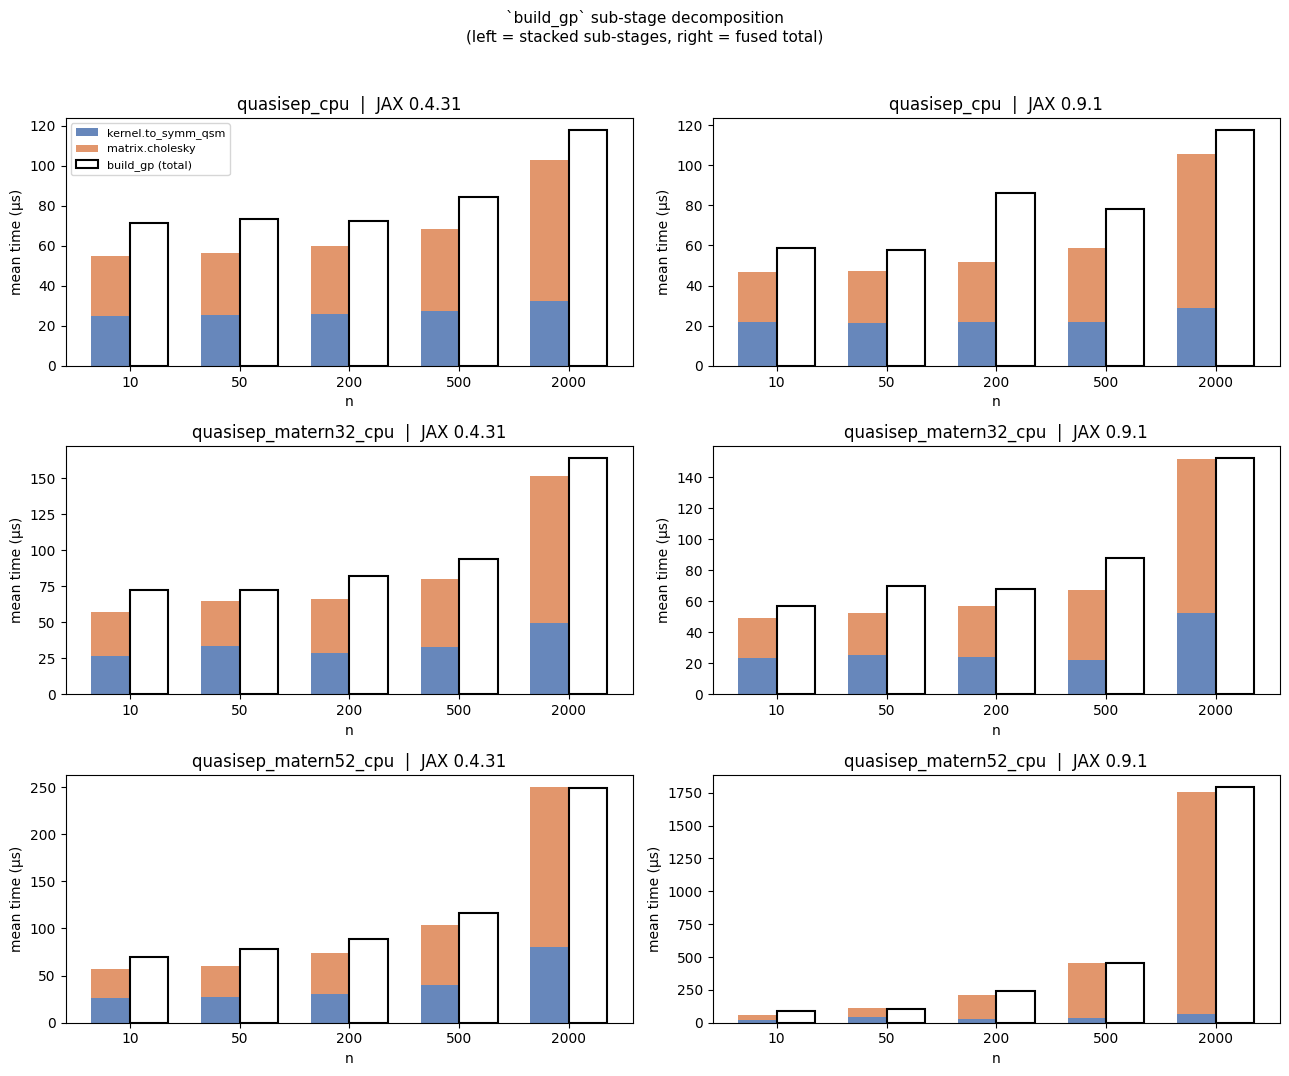

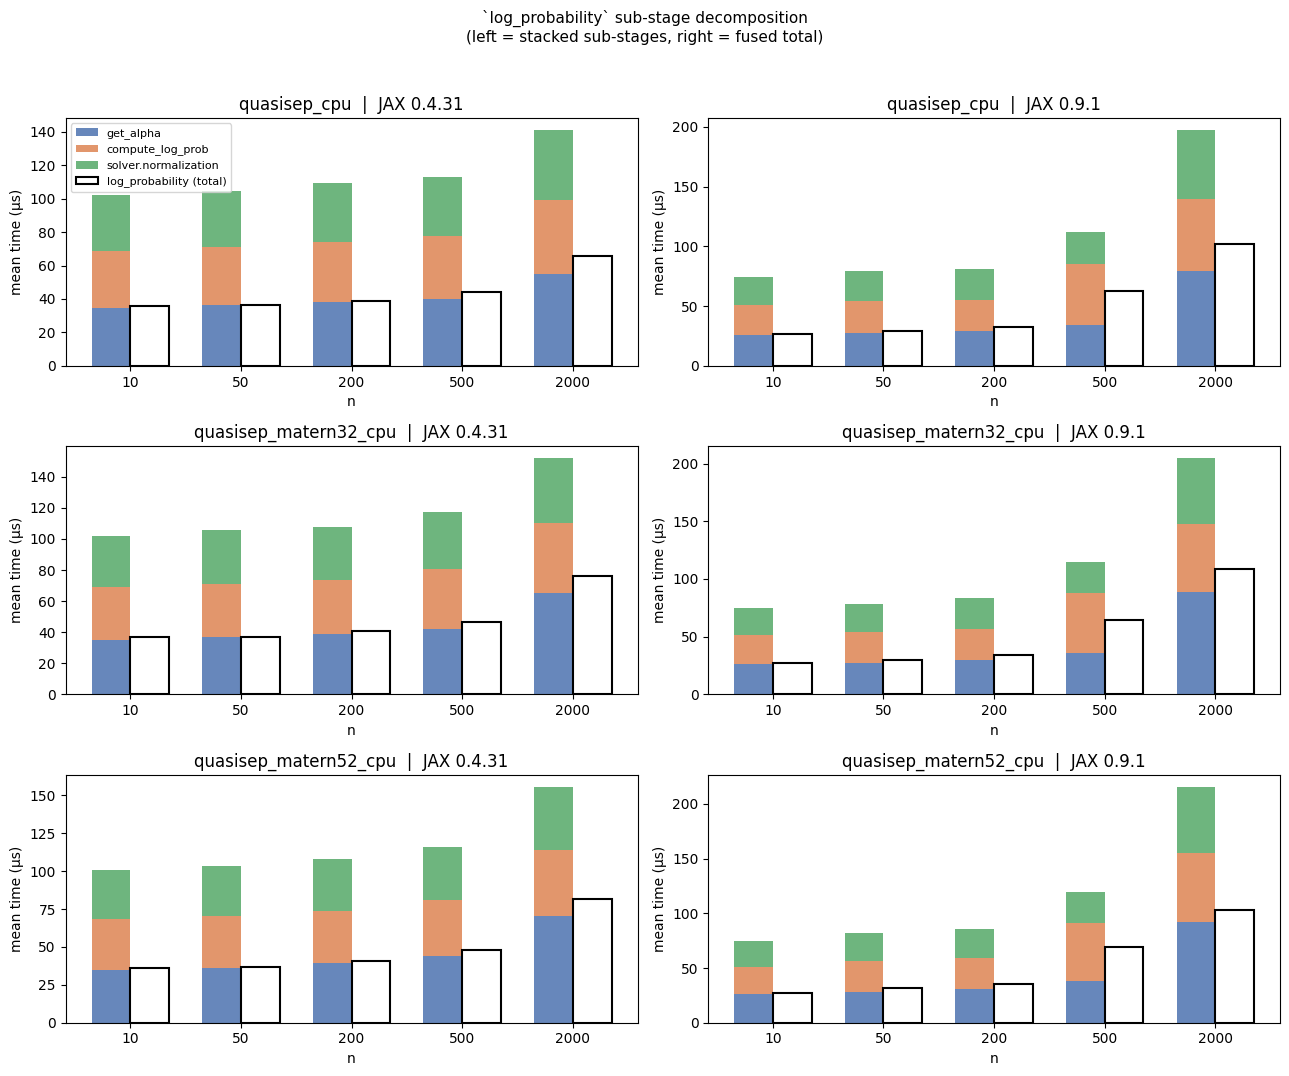

In [14]:
scenarios = sorted(df["scenario"].unique())
sizes = sorted(df["n"].unique())
jax_versions = [("mean_base_us", baseline["jax"]), ("mean_cand_us", candidate["jax"])]

build_sub = ["kernel.to_symm_qsm", "matrix.cholesky"]
logprob_sub = ["_get_alpha", "_compute_log_prob", "solver.normalization"]
sub_colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]


def display_label(s):
    """Strip leading underscore so matplotlib includes the entry in the legend."""
    return s.lstrip("_")


for parent, subs in [("build_gp", build_sub), ("log_probability", logprob_sub)]:
    fig, axes = plt.subplots(
        len(scenarios), len(jax_versions), figsize=(13, 3.5 * len(scenarios)), squeeze=False
    )

    for col, (col_key, jax_ver) in enumerate(jax_versions):
        for row, scenario in enumerate(scenarios):
            ax = axes[row][col]
            sub_df = df[df["scenario"] == scenario].set_index(["n", "stage"])[col_key].unstack("stage")

            x = np.arange(len(sizes))
            width = 0.35

            bottom = np.zeros(len(sizes))
            for i, sub in enumerate(subs):
                vals = np.array(
                    [sub_df.loc[n, sub] if n in sub_df.index and sub in sub_df.columns else 0.0
                     for n in sizes]
                )
                ax.bar(x - width / 2, vals, width, bottom=bottom,
                       label=display_label(sub), color=sub_colors[i], alpha=0.85)
                bottom += vals

            parent_vals = [sub_df.loc[n, parent] if n in sub_df.index and parent in sub_df.columns else 0.0
                           for n in sizes]
            ax.bar(x + width / 2, parent_vals, width, label=f"{parent} (total)",
                   color="none", edgecolor="black", linewidth=1.5)

            ax.set_xticks(x)
            ax.set_xticklabels(sizes)
            ax.set_xlabel("n")
            ax.set_ylabel("mean time (μs)")
            ax.set_title(f"{scenario}  |  JAX {jax_ver}")
            if row == 0 and col == 0:
                ax.legend(fontsize=8, loc="upper left")

    fig.suptitle(f"`{parent}` sub-stage decomposition\n(left = stacked sub-stages, right = fused total)",
                 fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## Ratio heatmap: which stage × scenario regresses?

Ratio > 1 = JAX 0.9 is slower. Focus on the largest n (2000) for the clearest signal.

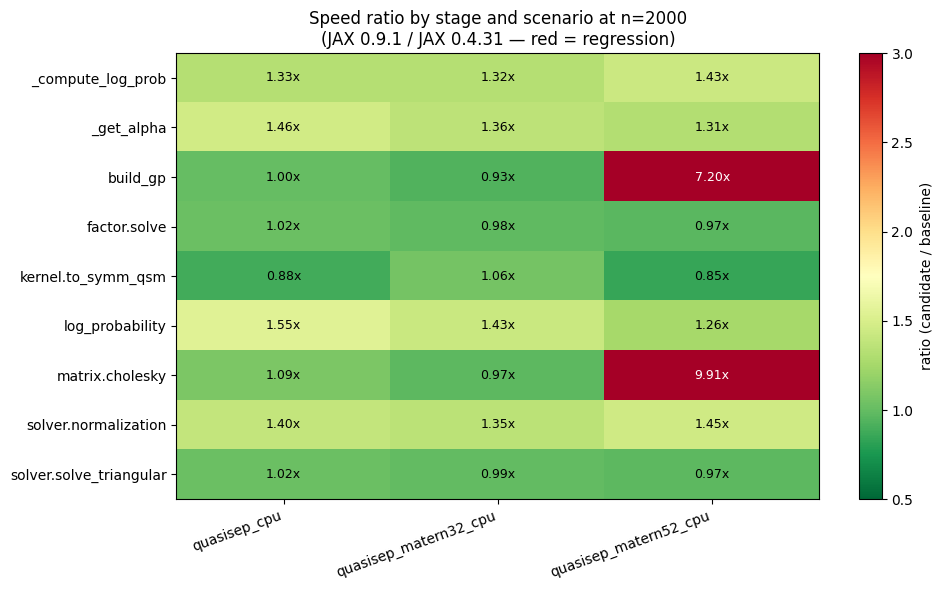

In [15]:
n_focus = df['n'].max()
pivot = df[df['n'] == n_focus].pivot(index='stage', columns='scenario', values='ratio')

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r', vmin=0.5, vmax=3.0)
plt.colorbar(im, ax=ax, label='ratio (candidate / baseline)')

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=20, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.2f}x', ha='center', va='center', fontsize=9,
                color='white' if val > 2.0 or val < 0.7 else 'black')

ax.set_title(f'Speed ratio by stage and scenario at n={n_focus}\n(JAX 0.9.1 / JAX 0.4.31 — red = regression)')
plt.tight_layout()
plt.show()

## Matern52 `build_gp` decomposition: `to_symm_qsm` vs `matrix.cholesky`

This is the key plot — does the regression live in kernel matrix construction or in the Cholesky scan?

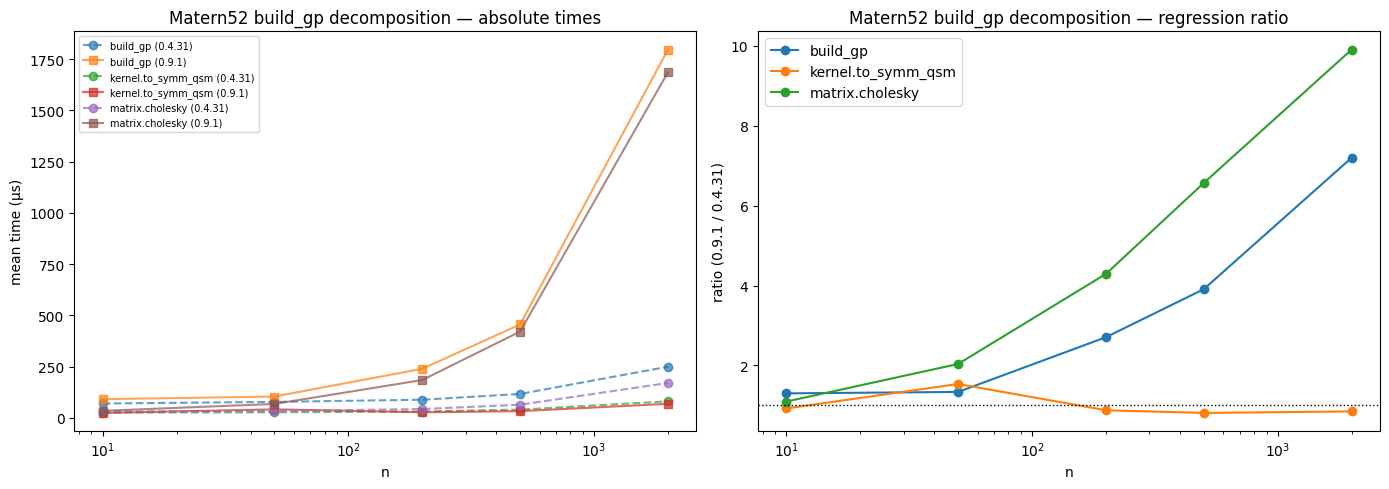

In [16]:
build_stages = ['build_gp', 'kernel.to_symm_qsm', 'matrix.cholesky']
m52 = df[(df['scenario'] == 'quasisep_matern52_cpu') & (df['stage'].isin(build_stages))].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for stage, grp in m52.groupby('stage'):
    grp = grp.sort_values('n')
    ax.plot(grp['n'], grp['mean_base_us'], 'o--', label=f'{stage} (0.4.31)', alpha=0.7)
    ax.plot(grp['n'], grp['mean_cand_us'], 's-',  label=f'{stage} (0.9.1)', alpha=0.7)
ax.set_xlabel('n')
ax.set_ylabel('mean time (μs)')
ax.set_title('Matern52 build_gp decomposition — absolute times')
ax.legend(fontsize=7)
ax.set_xscale('log')

ax = axes[1]
for stage, grp in m52.groupby('stage'):
    grp = grp.sort_values('n')
    ax.plot(grp['n'], grp['ratio'], 'o-', label=stage)
ax.axhline(1.0, color='k', linestyle=':', linewidth=1)
ax.set_xlabel('n')
ax.set_ylabel('ratio (0.9.1 / 0.4.31)')
ax.set_title('Matern52 build_gp decomposition — regression ratio')
ax.legend()
ax.set_xscale('log')

plt.tight_layout()
plt.show()

## All scenarios: `build_gp` sub-stages compared

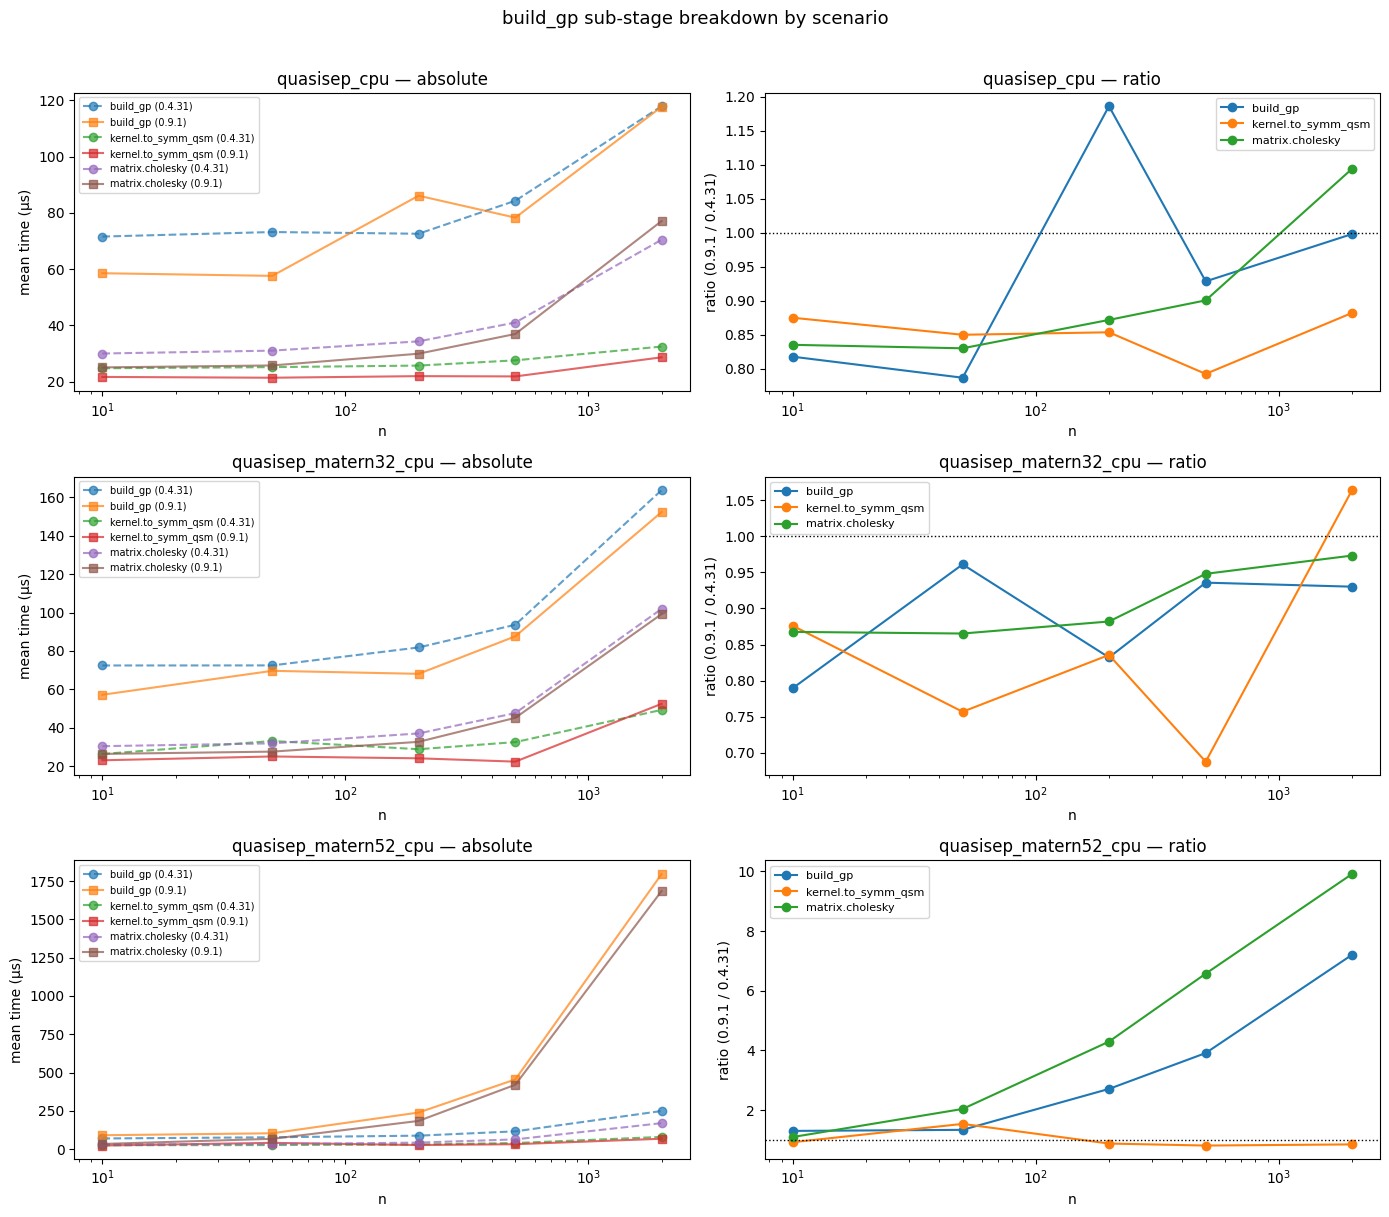

In [17]:
scenarios = sorted(df['scenario'].unique())
fig, axes = plt.subplots(len(scenarios), 2, figsize=(14, 4 * len(scenarios)), squeeze=False)

for row, scenario in enumerate(scenarios):
    sub = df[(df['scenario'] == scenario) & (df['stage'].isin(build_stages))].copy()

    ax = axes[row][0]
    for stage, grp in sub.groupby('stage'):
        grp = grp.sort_values('n')
        ax.plot(grp['n'], grp['mean_base_us'], 'o--', alpha=0.7, label=f'{stage} (0.4.31)')
        ax.plot(grp['n'], grp['mean_cand_us'], 's-',  alpha=0.7, label=f'{stage} (0.9.1)')
    ax.set_title(f'{scenario} — absolute')
    ax.set_xlabel('n')
    ax.set_ylabel('mean time (μs)')
    ax.legend(fontsize=7)
    ax.set_xscale('log')

    ax = axes[row][1]
    for stage, grp in sub.groupby('stage'):
        grp = grp.sort_values('n')
        ax.plot(grp['n'], grp['ratio'], 'o-', label=stage)
    ax.axhline(1.0, color='k', linestyle=':', linewidth=1)
    ax.set_title(f'{scenario} — ratio')
    ax.set_xlabel('n')
    ax.set_ylabel('ratio (0.9.1 / 0.4.31)')
    ax.legend(fontsize=8)
    ax.set_xscale('log')

plt.suptitle('build_gp sub-stage breakdown by scenario', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

## Full stage ratio table at largest n

In [18]:
table = df[df['n'] == n_focus][['scenario', 'stage', 'mean_base_us', 'mean_cand_us', 'ratio']].copy()
table = table.sort_values(['scenario', 'ratio'], ascending=[True, False])
table.columns = ['scenario', 'stage', 'baseline μs', 'candidate μs', 'ratio']
table.style.background_gradient(subset=['ratio'], cmap='RdYlGn_r', vmin=0.5, vmax=3.0) \
           .format({'baseline μs': '{:.1f}', 'candidate μs': '{:.1f}', 'ratio': '{:.2f}x'})

,scenario,stage,baseline μs,candidate μs,ratio
39,quasisep_cpu,log_probability,65.8,101.8,1.55x
40,quasisep_cpu,_get_alpha,54.6,79.7,1.46x
44,quasisep_cpu,solver.normalization,41.8,58.3,1.40x
43,quasisep_cpu,_compute_log_prob,44.8,59.5,1.33x
38,quasisep_cpu,matrix.cholesky,70.4,77.1,1.09x
42,quasisep_cpu,factor.solve,52.8,54.1,1.02x
41,quasisep_cpu,solver.solve_triangular,53.4,54.4,1.02x
36,quasisep_cpu,build_gp,117.9,117.7,1.00x
37,quasisep_cpu,kernel.to_symm_qsm,32.4,28.6,0.88x
84,quasisep_matern32_cpu,log_probability,76.0,108.4,1.43x
